Treniravimo ir testinių duomenų atsisiuntimas

In [22]:

classes = ["Tree", "Tomato", "Pizza"]


Duomenų atsisiuntimas

In [23]:
import fiftyone as fo
import fiftyone.zoo as foz

import fiftyone as fo
import fiftyone.zoo as foz


samples_per_class = 1000

# tuscias dataset, laikoma visas dataset
dataset = fo.Dataset("balanced-dataset")

# kiekvienai klasei yra atsisiunciami duomenys
for cls in classes:
    print(f"Downloading {cls}...")

    tmp_dataset = foz.load_zoo_dataset(
        "open-images-v7",
        split="train",
        label_types=["classifications"],
        classes=[cls],
        max_samples=samples_per_class,
        dataset_name=f"open-images-{cls}",
        drop_existing_dataset=True
    )

    # sujungiamas dataset
    dataset.merge_samples(tmp_dataset)

dataset = dataset.shuffle()

# is viso duomenu
print(f"Total samples: {len(dataset)}")



 100% |██████|    4.8Gb/4.8Gb [27.2s elapsed, 0s remaining, 210.0Mb/s]      
 100% |█████████████████| 1000/1000 [1.6m elapsed, 0s remaining, 10.0 files/s]      
Dataset info written to '/Users/elvinas/fiftyone/open-images-v7/info.json'
Loading 'open-images-v7' split 'train'
 100% |███████████████| 1000/1000 [2.1s elapsed, 0s remaining, 545.9 samples/s]      
Dataset 'open-images-Tree' created
Converting existing index 'filepath' to unique on dataset 'open-images-Tree'
Converting existing index 'filepath' to unique on dataset 'balanced-dataset'
Found 6 images, downloading the remaining 994
 100% |███████████████████| 994/994 [1.1m elapsed, 0s remaining, 15.2 files/s]      
Dataset info written to '/Users/elvinas/fiftyone/open-images-v7/info.json'
Loading 'open-images-v7' split 'train'
 100% |███████████████| 1000/1000 [1.5s elapsed, 0s remaining, 684.6 samples/s]         
Dataset 'open-images-Tomato' created
Converting existing index 'filepath' to unique on dataset 'open-images-Tomato'

In [24]:
from torch.utils.data import Dataset, random_split
from PIL import Image
import math

# dataset'as, leidziantis naudoti daugeli zymenu
class MultiLabelDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB") # paverciama i rgb, kad butu 3 inputai pradzioj
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

def load_fiftyone_samples(dataset, classes):
    samples = []
    for sample in dataset:
        img_path = sample.filepath
        present = set()
        absent = set()

        # yra tiek pozityviu, tiek negatyviu lable's
        if sample.positive_labels is not None:
            for cls in sample.positive_labels.classifications:
                if cls.label in classes:
                    present.add(cls.label)

        if sample.negative_labels is not None:
            for cls in sample.negative_labels.classifications:
                if cls.label in classes:
                    absent.add(cls.label)

        # kartais del klaidu, gali nebuti tinkamo label. kodel nematchina, idk
        label = []
        for c in classes:
            if c in present:
                label.append(1.0)
            elif c in absent:
                label.append(0.0)
            else:
                label.append(0.0)

        if sum(l for l in label if not math.isnan(l)) > 0:
            samples.append((img_path, label))

    return samples

# uzloadinti subalansuota dataset
import fiftyone as fo
dataset = fo.load_dataset("balanced-dataset")

all_samples = load_fiftyone_samples(dataset, classes)
print(f"Total samples with at least one label: {len(all_samples)}")

Total samples with at least one label: 1994


In [44]:
import torch
import torch.nn as nn

print(torch.backends.mps.is_available())
device = torch.device('mps')
print(device)

class ClassificationModel(nn.Module):
    def __init__(self):
        super(ClassificationModel, self).__init__()

        self.steps = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding='same'), # 3 -> 8
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.Conv2d(8, 8, kernel_size=3, padding='same'), # 8 -> 8
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 128x128 → 64x64
            nn.Conv2d(8, 16, kernel_size=3, padding='same'), # 8 -> 16
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 64x64 -> 32x32
            nn.Conv2d(16, 16, kernel_size=3, padding='same'), # 16 -> 16
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding='same'), # 16 -> 16
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 32x32 -> 16x16
            nn.Flatten(),
            nn.Linear(16 * 16 * 16, 64),
            nn.ReLU(),
            nn.Dropout(0.35),       # dropout, kad butu mokomasi, nes butu overfitting
            nn.Linear(64, 3)
        )

    def forward(self, x):
        x = self.steps(x)
        return x




True
mps


In [53]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transforms_train = transforms.Compose([
    transforms.Resize((128, 128)),       # pakeičia dydį į 128×128
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip()
])

transforms_test = transforms.Compose([
    transforms.Resize((128, 128)),       # pakeičia dydį į 128×128
    transforms.ToTensor(),
])

n_train = int(0.8 * len(all_samples))
n_test  = len(all_samples) - n_train
train_samples, test_samples = random_split(all_samples, [n_train, n_test])

# train_dataset = datasets.ImageFolder('data/train', transform = transforms_train)
# test_dataset = datasets.ImageFolder('data/test', transform = transforms_test)

train_dataset = MultiLabelDataset(list(train_samples), transform=transforms_train)
test_dataset  = MultiLabelDataset(list(test_samples),  transform=transforms_test)

num_workers = 0 # meta errorus kai daugiau, galbut del mano custom dataset
batch_size = 20

train_loader = DataLoader(train_dataset, batch_size = batch_size, num_workers = num_workers, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = batch_size, num_workers = num_workers, shuffle = False)

print(f'Train: {len(train_dataset)}, Test: {len(test_dataset)}')

Train: 1595, Test: 399


In [46]:
from datetime import datetime
import numpy as np
def train(model, loader, epoch_count = 10, lr = 1e-3):
    loss_func = torch.nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    start_time = datetime.now()

    for epoch in range(epoch_count):
        loss_acum = []
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            pred = model(images)
            loss = loss_func(pred, labels)
            loss.backward()
            optimizer.step()
            loss_acum.append(loss.item())
        current_time = datetime.now()
        elapsed = seconds_to_time((current_time - start_time).total_seconds())
        print(f'Epoch: {epoch}, Time: {elapsed}, Loss: {np.mean(loss_acum)}')



def seconds_to_time(seconds):
    s = int(seconds) % 60
    m = int(seconds) // 60
    if m < 1:
        return f'{s}s'
    h = m // 60
    m = m % 60
    if h < 1:
        return f'{m}m{s}s'
    return f'{h}h{m}m{s}s'

In [47]:
from sklearn.metrics import classification_report
def evaluate(model, loader, threshold=0.5):
    model.eval()

    correct_predictions = 0
    total_predictions = 0

    all_preds = []
    all_labels = []

    start_time = datetime.now()
    for data in loader:
        images = data[0].to(device)
        labels = data[1].to(device).float()

        with torch.no_grad():
            pred = model(images)

        # sigmoid'e, nes noriu, kad keletas klasiu galetu buti teisingos
        prob = torch.sigmoid(pred)
        label_pred = (prob >= threshold).float()

        # visi turi sutapti labeliai
        correct_predictions += (label_pred == labels).all(dim=1).sum()
        total_predictions += images.shape[0]

        all_preds.append(label_pred.cpu())
        all_labels.append(labels.cpu())

    current_time = datetime.now()
    per_image = (current_time - start_time).total_seconds() / total_predictions

    # visi predictionai ir labeliai - concatinate
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    exact_match = correct_predictions / total_predictions
    print(f'Time: {per_image * 1000:.2f}ms')
    print(f'Exact Match Accuracy:  {exact_match:.4f}')
    print()

    # library, kuri sugeneruoja reporta, kad nereiketu man paciam rasyt
    report = classification_report(
        all_labels,
        all_preds,
        target_names=classes,
        zero_division=0
    )
    print(report)


In [54]:
model = ClassificationModel().to(device)
print(f'Parameter count: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

train(model, train_loader, epoch_count = 20)
evaluate(model, test_loader)


Parameter count: 269,147
Epoch: 0, Time: 13s, Loss: 0.47689444981515405
Epoch: 1, Time: 25s, Loss: 0.38621595688164234
Epoch: 2, Time: 36s, Loss: 0.3519566712900996
Epoch: 3, Time: 47s, Loss: 0.3275280467234552
Epoch: 4, Time: 59s, Loss: 0.31646255059167744
Epoch: 5, Time: 1m10s, Loss: 0.30130536016076803
Epoch: 6, Time: 1m21s, Loss: 0.284796338621527
Epoch: 7, Time: 1m32s, Loss: 0.2815735581330955
Epoch: 8, Time: 1m44s, Loss: 0.2771475839428604
Epoch: 9, Time: 1m55s, Loss: 0.2562833218835294
Epoch: 10, Time: 2m6s, Loss: 0.23034683112055063
Epoch: 11, Time: 2m17s, Loss: 0.2421675213146955
Epoch: 12, Time: 2m28s, Loss: 0.23939526434987785
Epoch: 13, Time: 2m39s, Loss: 0.22485362812876702
Epoch: 14, Time: 2m50s, Loss: 0.19965156661346556
Epoch: 15, Time: 3m1s, Loss: 0.21419763499870897
Epoch: 16, Time: 3m12s, Loss: 0.19890255655627698
Epoch: 17, Time: 3m24s, Loss: 0.18354791468009352
Epoch: 18, Time: 3m39s, Loss: 0.1771599801722914
Epoch: 19, Time: 3m52s, Loss: 0.18457846571691333
Time: 

In [55]:
def print_class_balance(dataset, class_names, set_name):
    # dataset.samples yra - (image_path, label_vector)
    # label_vector yra sarasas kaip [1.0, 0.0, 1.0]

    counts = {c: 0 for c in class_names}
    total_samples = len(dataset)

    for _, label_vector in dataset.samples:
        for idx, value in enumerate(label_vector):
            if value == 1.0:
                counts[class_names[idx]] += 1

    print(f"--- {set_name} Balance ({total_samples} images) ---")
    for cls in class_names:
        count = counts[cls]
        percentage = (count / total_samples * 100) if total_samples > 0 else 0
        print(f"{cls:<10}: {count} ({percentage:.1f}%)")
    print()

# pasiziureti training ir test duomenu balansa
print_class_balance(train_dataset, classes, "Train Set")
print_class_balance(test_dataset, classes, "Test Set")

--- Train Set Balance (1595 images) ---
Tree      : 645 (40.4%)
Tomato    : 448 (28.1%)
Pizza     : 517 (32.4%)

--- Test Set Balance (399 images) ---
Tree      : 162 (40.6%)
Tomato    : 104 (26.1%)
Pizza     : 136 (34.1%)



In [42]:
evaluate(model, test_loader, 0.5)

Time: 6.97ms
Exact Match Accuracy:  0.7870

              precision    recall  f1-score   support

        Tree       0.92      0.83      0.87       164
      Tomato       0.83      0.61      0.70       112
       Pizza       0.74      0.91      0.82       127

   micro avg       0.83      0.79      0.81       403
   macro avg       0.83      0.78      0.80       403
weighted avg       0.84      0.79      0.81       403
 samples avg       0.80      0.79      0.79       403



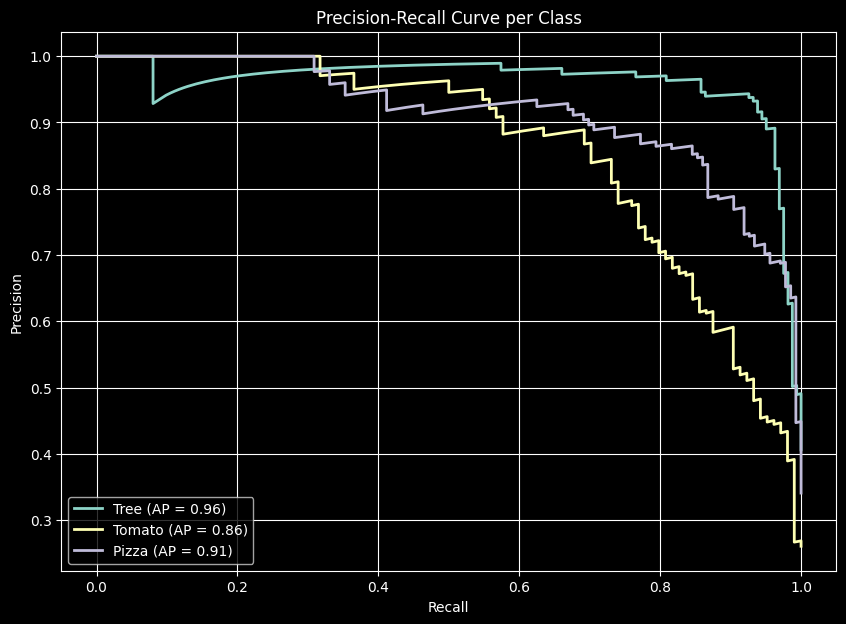

In [56]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_precision_recall(model, loader, class_names):
    model.eval()

    all_probs = []
    all_labels = []

    # surinkti visas prognozes ir tiesas
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits)  # sigmoide, nes daugelis zymenu

            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())

    # concat viska
    y_scores = torch.cat(all_probs).numpy()  # prognozes
    y_true = torch.cat(all_labels).numpy()   # tiesos


    plt.figure(figsize=(10, 7))

    # kiekvienai klasei po linija
    for i, class_name in enumerate(class_names):
        precision, recall, _ = precision_recall_curve(y_true[:, i], y_scores[:, i])
        average_precision = average_precision_score(y_true[:, i], y_scores[:, i])

        plt.plot(recall, precision, lw=2, label=f'{class_name} (AP = {average_precision:.2f})')

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve per Class")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

plot_precision_recall(model, test_loader, classes)